Found 5394 rows in CSV matching the filters. Checking files...
Verified 816 valid samples for training.
Split dataset: 720 for training, 96 for validation.

--- Epoch 1/15 ---
Step   12/720 | Batch Avg Det: 0.4209 | W-NPS: 0.1335 | W-TV: 0.6741 | W-Style: 3.5351 | YOLO force: 3.592740 | Style force: 1.608851 | NPS & TV force: 0.476624
Step   24/720 | Batch Avg Det: 0.4150 | W-NPS: 1.3452 | W-TV: 1.3219 | W-Style: 5.6737 | YOLO force: 3.940002 | Style force: 2.579832 | NPS & TV force: 0.595194
Step   36/720 | Batch Avg Det: 0.3032 | W-NPS: 1.7447 | W-TV: 1.7121 | W-Style: 5.5608 | YOLO force: 2.117068 | Style force: 2.247639 | NPS & TV force: 0.593106
Step   48/720 | Batch Avg Det: 0.4627 | W-NPS: 1.9849 | W-TV: 1.9101 | W-Style: 5.3293 | YOLO force: 5.892831 | Style force: 1.951436 | NPS & TV force: 0.594739
Step   60/720 | Batch Avg Det: 0.4560 | W-NPS: 2.1863 | W-TV: 2.0457 | W-Style: 5.4531 | YOLO force: 3.870579 | Style force: 2.040376 | NPS & TV force: 0.596740
Step   72/720 | Bat

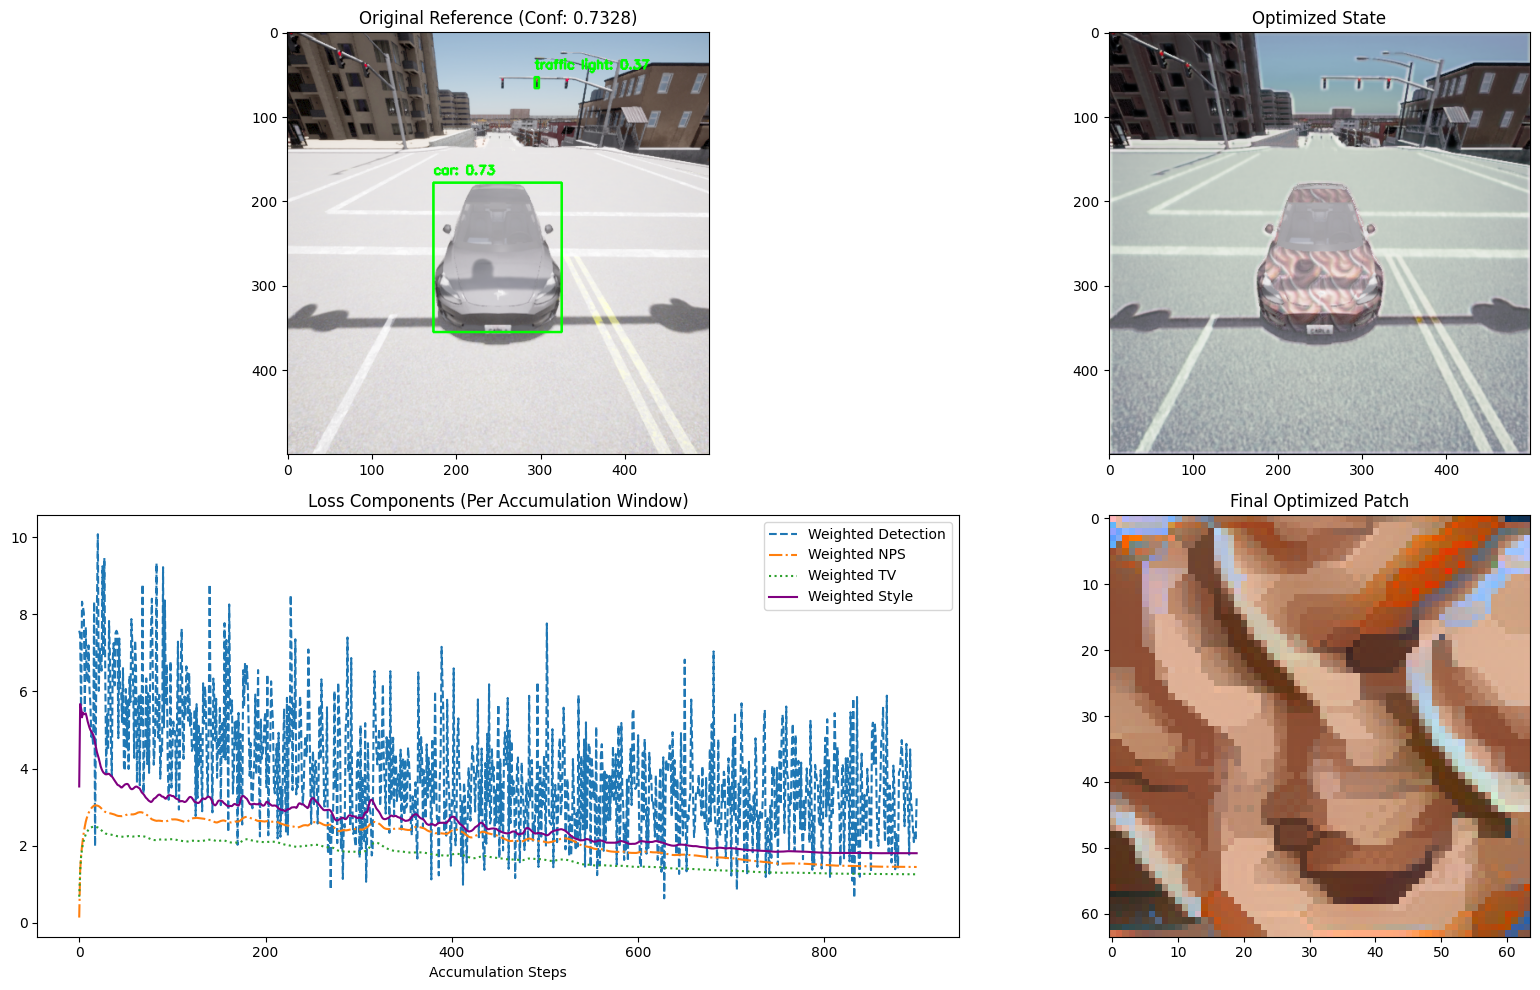

In [16]:
import tensorflow as tf
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# ========== HARDWARE ACCELERATION ==========
# Enable XLA compilation for faster math
tf.config.optimizer.set_jit(True) 
# Enable Mixed Precision (uses fp16 for speed, fp32 for stability)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ========== CONFIGURATION ==========

DATASET_FOLDER      = 'sample_dataset'
METADATA_CSV        = os.path.join(DATASET_FOLDER, 'metadata.csv')

# Limit dataset size for testing
TRAIN_SAMPLES    =  720
VAL_SPLIT_SIZE = 96

MAX_SAMPLES = TRAIN_SAMPLES + VAL_SPLIT_SIZE

# Dataset Filters
ALLOWED_DISTANCES = [5, 7] # [5, 7, 10]
ALLOWED_PITCHES   = [30] # [10, 30, 45]

EPOCHS              = 15
ACCUMULATION_STEPS  = 12 # batch size

MODEL_PATH_RENDERER = 'models/k3_100epch_wo_custom_loss_model.h5'
MODEL_PATH_YOLO     = 'yolov8n_saved_model'

IMG_SIZE            = (500, 500)
YOLO_SIZE           = (640, 640)
TEX_RES             = 64
TEX_UPSCALE_RES     = 256

INITIAL_TEX_PATH    = 'textures/camo_muddy.png'
STYLE_IMAGE_PATH    = 'textures/camo_muddy.png'

ATTACK_MODE         = 'misclassification'   # 'hide' or 'misclassification'

DETECTION_WEIGHT    = 18.0
TV_WEIGHT           = 12.0
NPS_WEIGHT          = 25.0
STYLE_WEIGHT        = 4e-10 * 1.75

LEARNING_RATE = 0.035

STEPS_PER_EPOCH = TRAIN_SAMPLES // ACCUMULATION_STEPS
TOTAL_OPTIMIZER_STEPS = STEPS_PER_EPOCH * EPOCHS

VEHICLE_CLASS_IDS   = [2, 7, 5]  # car, truck, bus

CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus',
    6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant',
    11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat',
    16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear',
    22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag',
    27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard',
    32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove',
    36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle',
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl',
    46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli',
    51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake',
    56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table',
    61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard',
    67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink',
    72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors',
    77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'
}

# ========== SETUP ========== 

renderer_model = tf.keras.models.load_model(MODEL_PATH_RENDERER, compile=False)
yolo_loaded    = tf.saved_model.load(MODEL_PATH_YOLO)
yolo_infer     = yolo_loaded.signatures['serving_default']

tf.keras.mixed_precision.set_global_policy('float32')
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False
style_layers    = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
style_extractor = tf.keras.Model([vgg.input], [vgg.get_layer(n).output for n in style_layers])
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def extract_target_colour_palette(img_path, num_colours=16):
    #extract the dominant colours from target image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #flatten to list of rgb scaled as 0.0 to 1.0
    pixels = img.reshape((-1, 3)).astype(np.float32) / 255.0

    #k-means clustering to find dominant colours
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TermCriteria_MAX_ITER, 100, 0.01)
    _, _, centers = cv2.kmeans(pixels, num_colours, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    return tf.constant(centers, dtype=tf.float32)

TARGET_COLOURS = extract_target_colour_palette(STYLE_IMAGE_PATH, num_colours=16)



def gram_matrix(x):
    x = tf.cast(x, tf.float32)
    return tf.linalg.einsum('bijc,bijd->bcd', x, x) / tf.cast(tf.shape(x)[1] * tf.shape(x)[2], tf.float32)

def load_image_for_style(path):
    img = tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(path), channels=3), tf.float32)
    return tf.expand_dims(tf.image.resize(img, [TEX_UPSCALE_RES, TEX_UPSCALE_RES]), 0)

target_style_img = load_image_for_style(STYLE_IMAGE_PATH)
TARGET_GRAMS = [gram_matrix(f) for f in style_extractor(tf.keras.applications.vgg19.preprocess_input(target_style_img * 255.0))]

initial_tex = load_image_for_style(INITIAL_TEX_PATH)
# Force fp32 for our optimized variable to prevent precision loss during accumulation
tf_texture  = tf.Variable(tf.image.resize(initial_tex, [TEX_RES, TEX_RES])[0], dtype=tf.float32)
gradient_accumulator = tf.Variable(tf.zeros_like(tf_texture), trainable=False, dtype=tf.float32)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=TOTAL_OPTIMIZER_STEPS,
    alpha=0.01
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

os.makedirs('natural_checkpoints', exist_ok=True) # Directory for saving patches

# ========== SAFE DATASET PIPELINE ==========

df_meta = pd.read_csv(METADATA_CSV)

# 1. Instantly filter the dataframe to only keep allowed distances and pitches
if ALLOWED_DISTANCES:
    df_meta = df_meta[df_meta['distance'].isin(ALLOWED_DISTANCES)]
if ALLOWED_PITCHES:
    df_meta = df_meta[df_meta['pitch'].isin(ALLOWED_PITCHES)]

print(f"Found {len(df_meta)} rows in CSV matching the filters. Checking files...")

valid_filenames, valid_distances, valid_pitches, valid_yaws = [], [], [], []

# 2. Iterate through the FILTERED dataframe to check file existence
for idx, row in df_meta.iterrows():
    if len(valid_filenames) >= MAX_SAMPLES:
        break
        
    base_name = str(row['filename']).zfill(5)
    ref_path = os.path.join(DATASET_FOLDER, 'reference', f"{base_name}.png")
    mask_path = os.path.join(DATASET_FOLDER, 'masks', f"{base_name}.png")
    overlay_path = os.path.join(DATASET_FOLDER, 'overlays', f"{base_name}.png")
    
    # Only include if all 3 files exist
    if os.path.exists(ref_path) and os.path.exists(mask_path) and os.path.exists(overlay_path):
        valid_filenames.append(f"{base_name}.png")
        valid_distances.append(np.float32(row['distance']))
        valid_pitches.append(np.float32(row['pitch']))
        valid_yaws.append(np.float32(row['yaw']))

NUM_SAMPLES = len(valid_filenames)
print(f"Verified {NUM_SAMPLES} valid samples for training.")

def process_path(filename, distance, pitch, yaw):
    ref_path     = tf.strings.join([DATASET_FOLDER, tf.constant('/reference/'), filename])
    mask_path    = tf.strings.join([DATASET_FOLDER, tf.constant('/masks/'), filename])
    overlay_path = tf.strings.join([DATASET_FOLDER, tf.constant('/overlays/'), filename])

    def read_img(path):
        img = tf.image.decode_png(tf.io.read_file(path), channels=3)
        return tf.image.resize(tf.image.convert_image_dtype(img, tf.float32), IMG_SIZE)

    return read_img(ref_path), read_img(mask_path), read_img(overlay_path), tf.stack([distance, pitch, yaw])

def create_dataset():
    ds = tf.data.Dataset.from_tensor_slices((valid_filenames, valid_distances, valid_pitches, valid_yaws))
    ds = ds.shuffle(buffer_size=NUM_SAMPLES)
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# ========== RENDERING & LOSS ==========

def calc_transforms(pitch, yaw):
    yaw_diff   = ((yaw + 45.0) % 90.0) - 45.0
    cond_front = tf.logical_and(yaw > 145.0, yaw < 215.0)
    p = tf.where(cond_front, -pitch, pitch)
    y = tf.where(cond_front, -yaw_diff, 0.0)
    r = tf.where(cond_front, 0.0, -yaw_diff)
    p = tf.where(pitch < 15.0, pitch,  p);  y = tf.where(pitch < 15.0, 0.0,       y);  r = tf.where(pitch < 15.0, -yaw_diff, r)
    p = tf.where(pitch > 35.0, -pitch, p);  y = tf.where(pitch > 35.0, -yaw_diff, y);  r = tf.where(pitch > 35.0, 0.0,       r)
    return p, y, r

def get_rotation_matrix(pitch, yaw, roll):
    s = np.pi / 180.0
    p, y, r = pitch * s, yaw * s, roll * s
    Rp = tf.stack([[1., 0., 0.], [0., tf.cos(p), -tf.sin(p)], [0., tf.sin(p), tf.cos(p)]])
    Rr = tf.stack([[tf.cos(r), 0., tf.sin(r)], [0., 1., 0.], [-tf.sin(r), 0., tf.cos(r)]])
    Ry = tf.stack([[tf.cos(y), -tf.sin(y), 0.], [tf.sin(y), tf.cos(y), 0.], [0., 0., 1.]])
    return tf.matmul(Rp, tf.matmul(Rr, Ry))

@tf.function
def render_texture(texture, pitch, yaw, roll, distance, uv_scale=100.0, shift_u=0.0, shift_v=0.0):
    out_h, out_w = IMG_SIZE
    f  = 500.0
    high_res_tex = tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES], method='nearest')
    R            = get_rotation_matrix(pitch, yaw, roll)
    plane_normal = R[:, 2]
    plane_point  = plane_normal * (distance * 100.0)

    grid_x, grid_y = tf.meshgrid(tf.range(out_w), tf.range(out_h))
    ray_dir    = tf.stack([tf.cast(grid_x, tf.float32) - out_w/2.0, tf.cast(grid_y, tf.float32) - out_h/2.0, tf.ones([out_h, out_w]) * f], axis=-1)
    camera_pos = tf.constant([0.0, 0.0, -f])

    denom = tf.tensordot(ray_dir, plane_normal, axes=1)
    denom = tf.where(tf.abs(denom) < 1e-5, 1e-5, denom)
    t     = tf.tensordot(plane_point - camera_pos, plane_normal, axes=1) / denom

    hit_point = camera_pos + ray_dir * tf.expand_dims(t, -1)
    p_local   = tf.reshape(tf.matmul(tf.reshape(hit_point - plane_point, [-1, 3]), R), [out_h, out_w, 3])

    u = tf.math.floormod(p_local[:, :, 0] / uv_scale + shift_u, 1.0)
    v = tf.math.floormod(p_local[:, :, 1] / uv_scale + shift_v, 1.0)

    tex_h = tf.cast(tf.shape(high_res_tex)[0], tf.float32)
    tex_w = tf.cast(tf.shape(high_res_tex)[1], tf.float32)

    x, y_ = u * (tex_w - 1.0), v * (tex_h - 1.0)
    x  = tf.clip_by_value(x,  0.0, tex_w - 1.001)
    y_ = tf.clip_by_value(y_, 0.0, tex_h - 1.001)
    x0, y0 = tf.cast(tf.floor(x), tf.int32), tf.cast(tf.floor(y_), tf.int32)
    x1, y1 = x0 + 1, y0 + 1
    Ia, Ib = tf.gather_nd(high_res_tex, tf.stack([y0, x0], axis=-1)), tf.gather_nd(high_res_tex, tf.stack([y1, x0], axis=-1))
    Ic, Id = tf.gather_nd(high_res_tex, tf.stack([y0, x1], axis=-1)), tf.gather_nd(high_res_tex, tf.stack([y1, x1], axis=-1))
    wa = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (tf.cast(y1, tf.float32) - y_), -1)
    wb = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (y_ - tf.cast(y0, tf.float32)), -1)
    wc = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (tf.cast(y1, tf.float32) - y_), -1)
    wd = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (y_ - tf.cast(y0, tf.float32)), -1)
    output = tf.add_n([wa*Ia, wb*Ib, wc*Ic, wd*Id])

    return tf.where(tf.expand_dims(t > 0.0, -1), output, tf.zeros_like(output))

@tf.function
def compute_image_gradients(ref_img, mask_img, overlay_img, trans_tf, shift_u, shift_v):
    dist, pitch, yaw = trans_tf[0], trans_tf[1], trans_tf[2]
    p, y, r = calc_transforms(pitch, yaw)

    with tf.GradientTape() as tape:
        rendered   = render_texture(tf_texture, p, y, r, dist, shift_u=shift_u, shift_v=shift_v)
        tex_masked = tf.where(tf.reduce_max(mask_img, axis=-1, keepdims=True) > 0.1, rendered, tf.zeros_like(rendered))
        
        # Explicit FP32 casts for safety with Mixed Precision
        ref_f32 = tf.cast(ref_img, tf.float32)
        tex_masked_f32 = tf.cast(tex_masked, tf.float32)
        renderer_out = renderer_model([tf.expand_dims(ref_f32, 0), tf.expand_dims(tex_masked_f32, 0)], training=False)[0]
        
        adv_img  = tf.where(tf.reduce_max(overlay_img, axis=-1, keepdims=True) > 0.05, ref_img, renderer_out)
        yolo_in  = tf.cast(tf.image.resize(tf.expand_dims(adv_img, 0), YOLO_SIZE), tf.float32)
        yolo_out = yolo_infer(images=yolo_in)['output_0']

        all_class_scores = yolo_out[0, 4:, :]
        vehicle_scores   = tf.reduce_max(tf.gather(all_class_scores, VEHICLE_CLASS_IDS, axis=0), axis=0)
        
        if ATTACK_MODE == 'misclassification':
            all_idx = tf.range(tf.shape(all_class_scores)[0])
            non_vehicle_mask = tf.reduce_all(tf.not_equal(tf.expand_dims(all_idx, 1), tf.constant(VEHICLE_CLASS_IDS, dtype=all_idx.dtype)), axis=1)
            non_vehicle_scores = tf.reduce_max(tf.boolean_mask(all_class_scores, non_vehicle_mask, axis=0), axis=0)
            det_loss = tf.reduce_max(vehicle_scores - non_vehicle_scores)
        else:
            det_loss = tf.reduce_max(vehicle_scores)
            
        det_weighted_loss = DETECTION_WEIGHT * det_loss

    grads = tape.gradient(det_weighted_loss, tf_texture)
    return grads, det_loss, adv_img, yolo_out

@tf.function
def apply_accumulated_gradients(accumulated_image_grads, num_steps):
    averaged_image_grads = accumulated_image_grads / tf.cast(num_steps, tf.float32)
    
    with tf.GradientTape(persistent=True) as tape:
        tex_f32 = tf.cast(tf_texture, tf.float32) # Explicit FP32

        tv_loss  = TV_WEIGHT * tf.reduce_sum(tf.image.total_variation(tex_f32)) / tf.cast(tf.size(tex_f32), tf.float32)
        nps_loss = NPS_WEIGHT * tf.reduce_mean(tf.reduce_min(tf.sqrt(tf.reduce_sum(tf.square(tf.expand_dims(tf.reshape(tex_f32, [-1, 3]), 1) - TARGET_COLOURS) + 1e-8, axis=-1)), axis=1))
        
        tex_vgg    = style_extractor(tf.keras.applications.vgg19.preprocess_input(tf.expand_dims(tf.image.resize(tex_f32, [TEX_UPSCALE_RES, TEX_UPSCALE_RES]), 0) * 255.0))
        style_loss =  STYLE_WEIGHT * tf.add_n([tf.reduce_mean(tf.square(gram_matrix(f) - tg)) for f, tg in zip(tex_vgg, TARGET_GRAMS)]) / len(style_layers)
        
        nps_tv_loss= tv_loss + nps_loss

    style_grads = tape.gradient(style_loss, tf_texture)
    nps_tv_grads = tape.gradient(nps_tv_loss, tf_texture)

    final_grads   = averaged_image_grads + nps_tv_grads + style_grads


    yolo_force = tf.norm(averaged_image_grads)
    style_force = tf.norm(style_grads)
    nps_tv_force = tf.norm(nps_tv_grads)

    
    optimizer.apply_gradients([(final_grads, tf_texture)])
    tf_texture.assign(tf.clip_by_value(tf_texture, 0.0, 1.0))
    
    return tv_loss, nps_loss, style_loss, yolo_force, style_force, nps_tv_force

def draw_yolo_results(image_tf, yolo_output, conf_thresh=0.25):
    img    = (image_tf.numpy() * 255).astype(np.uint8).copy()
    output = np.transpose(yolo_output.numpy()[0])
    scale  = [IMG_SIZE[1] / YOLO_SIZE[1], IMG_SIZE[0] / YOLO_SIZE[0]] * 2

    boxes, confs, class_ids = [], [], []
    for row in output:
        cls_id = np.argmax(row[4:])
        score  = row[4:][cls_id]
        if score > conf_thresh:
            cx, cy, w, h = row[:4] * scale
            boxes.append([int(cx - w/2), int(cy - h/2), int(w), int(h)])
            confs.append(float(score));  class_ids.append(cls_id)

    indices = cv2.dnn.NMSBoxes(boxes, confs, conf_thresh, 0.45)
    if len(indices) > 0:
        for i in indices.flatten():
            bx, by, bw, bh = boxes[i]
            cv2.rectangle(img, (bx, by), (bx+bw, by+bh), (0, 255, 0), 2)
            cv2.putText(img, f"{CLASSES.get(class_ids[i], 'obj')}: {confs[i]:.2f}", (bx, by-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img

# ========== DATASET SPLIT & MAIN LOOP ==========


train_filenames = valid_filenames[:-VAL_SPLIT_SIZE]
train_distances = valid_distances[:-VAL_SPLIT_SIZE]
train_pitches   = valid_pitches[:-VAL_SPLIT_SIZE]
train_yaws      = valid_yaws[:-VAL_SPLIT_SIZE]

val_filenames = valid_filenames[-VAL_SPLIT_SIZE:]
val_distances = valid_distances[-VAL_SPLIT_SIZE:]
val_pitches   = valid_pitches[-VAL_SPLIT_SIZE:]
val_yaws      = valid_yaws[-VAL_SPLIT_SIZE:]

NUM_TRAIN = len(train_filenames)
print(f"Split dataset: {NUM_TRAIN} for training, {VAL_SPLIT_SIZE} for validation.")

def create_dataset_split(f, d, p, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((f, d, p, y))
    if shuffle: ds = ds.shuffle(buffer_size=len(f))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

history = {'det': [], 'tv': [], 'nps': [], 'style': [], 'val_det': []}

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    
    train_dataset = create_dataset_split(train_filenames, train_distances, train_pitches, train_yaws, shuffle=True)
    gradient_accumulator.assign(tf.zeros_like(tf_texture))
    accumulated_count = 0
    step_det_losses = [] 
    
    last_tv, last_nps, last_style = 0.0, 0.0, 0.0
    
    # --- TRAINING LOOP ---
    for step, (ref, mask, overlay, trans_tf) in enumerate(train_dataset):
        shift_u = tf.random.uniform(shape=[], minval=0.0, maxval=1.0)
        shift_v = tf.random.uniform(shape=[], minval=0.0, maxval=1.0)

        grads, det_loss, cur_adv, cur_yolo = compute_image_gradients(ref, mask, overlay, trans_tf, shift_u, shift_v)
        gradient_accumulator.assign_add(grads)
        accumulated_count += 1
        step_det_losses.append(det_loss.numpy())

        # Clean modulo check for flushing
        if (step + 1) % ACCUMULATION_STEPS == 0:
            tv_val, nps_val, style_val, yolo_force, style_force, nps_tv_force = apply_accumulated_gradients(gradient_accumulator, accumulated_count)

            last_tv, last_nps, last_style = tv_val.numpy(), nps_val.numpy(), style_val.numpy()
            current_avg_det = np.mean(step_det_losses)
            
            # Print BEFORE we clear the array!
            print(f"Step {step+1:4d}/{NUM_TRAIN} | Batch Avg Det: {current_avg_det:.4f} | W-NPS: {last_nps:.4f} | W-TV: {last_tv:.4f} | W-Style: {last_style:.4f} | YOLO force: {yolo_force.numpy():.6f} | Style force: {style_force.numpy():.6f} | NPS & TV force: {nps_tv_force.numpy():.6f}")

            history['det'].append(current_avg_det)
            history['tv'].append(last_tv); history['nps'].append(last_nps); history['style'].append(last_style)
            
            gradient_accumulator.assign(tf.zeros_like(tf_texture))
            accumulated_count = 0
            step_det_losses = []

    # Unconditional safety flush at end of epoch
    if accumulated_count > 0:
        tv_val, nps_val, style_val = apply_accumulated_gradients(gradient_accumulator, accumulated_count)
        history['det'].append(np.mean(step_det_losses))
        history['tv'].append(tv_val.numpy()); history['nps'].append(nps_val.numpy()); history['style'].append(style_val.numpy())

    # --- VALIDATION LOOP ---
    val_dataset = create_dataset_split(val_filenames, val_distances, val_pitches, val_yaws, shuffle=False)
    val_losses = []
    
    for val_ref, val_mask, val_overlay, val_trans in val_dataset:
        # Pass through without gradients
        _, v_det, _, _ = compute_image_gradients(val_ref, val_mask, val_overlay, val_trans, 0.0, 0.0)
        val_losses.append(v_det.numpy())
        
    epoch_val_det = np.mean(val_losses)
    history['val_det'].append(epoch_val_det)

    current_lr = lr_schedule(optimizer.iterations).numpy()
    
    print(f">> EPOCH {epoch+1} SUMMARY | Train Det: {np.mean(history['det'][-(NUM_TRAIN//ACCUMULATION_STEPS):]):.4f} | Val Det: {epoch_val_det:.4f} | LR: {current_lr:.6f} <<")

    # Checkpoint the texture
    patch_bgr = cv2.cvtColor((tf.clip_by_value(tf_texture, 0.0, 1.0).numpy() * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.imwrite(f"natural_checkpoints/patch_epoch_{epoch+1}.png", patch_bgr)

print("\nTraining complete. Patch saved to natural_checkpoints folder.")

# ========== VISUALISATION ==========
print("Visualizing results on a random test image from the loaded dataset...")

# Fetch one random sample from our validated lists
test_idx = np.random.randint(0, NUM_SAMPLES)
test_base_name = valid_filenames[test_idx]
ref_test = tf.image.resize(tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(os.path.join(DATASET_FOLDER, 'reference', test_base_name)), channels=3), tf.float32), IMG_SIZE)
mask_test = tf.image.resize(tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(os.path.join(DATASET_FOLDER, 'masks', test_base_name)), channels=3), tf.float32), IMG_SIZE)
overlay_test = tf.image.resize(tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(os.path.join(DATASET_FOLDER, 'overlays', test_base_name)), channels=3), tf.float32), IMG_SIZE)
trans_tf_test = tf.constant(np.array([valid_distances[test_idx], valid_pitches[test_idx], valid_yaws[test_idx]], dtype=np.float32))

# Baseline detection
ref_f32 = tf.cast(ref_test, tf.float32)
ref_yolo_in = tf.cast(tf.image.resize(tf.expand_dims(ref_f32, 0), YOLO_SIZE), tf.float32)
ref_yolo_out = yolo_infer(images=ref_yolo_in)['output_0']
ref_max_conf = tf.reduce_max(tf.stack([ref_yolo_out[0, 4 + c, :] for c in VEHICLE_CLASS_IDS]))

# Attack with Final Optimized Texture
p_test, y_test, r_test = calc_transforms(trans_tf_test[1], trans_tf_test[2])
test_rendered     = render_texture(tf_texture, p_test, y_test, r_test, trans_tf_test[0])
test_tex_masked   = tf.where(tf.reduce_max(mask_test, axis=-1, keepdims=True) > 0.1, test_rendered, tf.zeros_like(test_rendered))
test_renderer_out = renderer_model([tf.expand_dims(ref_f32, 0), tf.expand_dims(tf.cast(test_tex_masked, tf.float32), 0)], training=False)[0]
test_adv          = tf.where(tf.reduce_max(overlay_test, axis=-1, keepdims=True) > 0.05, ref_test, test_renderer_out)
test_yolo_in      = tf.cast(tf.image.resize(tf.expand_dims(test_adv, 0), YOLO_SIZE), tf.float32)
test_yolo         = yolo_infer(images=test_yolo_in)['output_0']

weighted_det_history = [x * DETECTION_WEIGHT for x in history['det']]

# Plot Results
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1);  plt.imshow(draw_yolo_results(ref_test, ref_yolo_out));   plt.title(f"Original Reference (Conf: {ref_max_conf.numpy():.4f})")
plt.subplot(2, 2, 2);  plt.imshow(draw_yolo_results(test_adv, test_yolo));      plt.title(f"Optimized State")

plt.subplot(2, 2, 3)
plt.plot(weighted_det_history,   label='Weighted Detection',      linestyle='--')
plt.plot(history['nps'],   label='Weighted NPS',   linestyle='-.')
plt.plot(history['tv'],    label='Weighted TV',    linestyle=':')
plt.plot(history['style'], label='Weighted Style', linestyle='-', color='purple')
plt.title("Loss Components (Per Accumulation Window)");  plt.xlabel("Accumulation Steps");  plt.legend()

plt.subplot(2, 2, 4);  
plt.imshow(tf.clip_by_value(tf_texture, 0.0, 1.0).numpy()); plt.title("Final Optimized Patch")

plt.tight_layout()
plt.show()